# Gradient Desent
Gradient descent is an optimization algorithm used to minimize a function by iteratively moving towards the steepest descent direction, which is determined by the negative of the gradient. It is commonly used in machine learning and deep learning to optimize the parameters of models.\
The basic idea is to update the parameters in the opposite direction of the gradient of the loss function with respect to the parameters. 

Let a best fit line be $y = mx + c$ where $m$ is the slope and $c$ is the y-intercept. The cost function, which we want to minimize, can be defined as:
$$J(m, c) = \frac{1}{n} \sum_{i=1}^{n} (y_i - (mx_i + c))^2$$
Where $n$ is the number of data points, $y_i$ is the actual value, and $mx_i + c$ is the predicted value.

Now J(m, c) is a function of two variables, $m$ and $c$. To minimize this cost function, we can use gradient descent. The update rules for the parameters $m$ and $c$ are given by:$$m := m - \alpha \frac{\partial J(m, c)}{\partial m}$$
$$c := c - \alpha \frac{\partial J(m, c)}{\partial c}$$
Where $\alpha$ is the learning rate, which controls the step size of the updates. The gradients $\frac{\partial J(m, c)}{\partial m}$ and $\frac{\partial J(m, c)}{\partial c}$ can be computed as follows:$$\frac{\partial J(m, c)}{\partial m} = -\frac{2}{n} \sum_{i=1}^{n} x_i (y_i - (mx_i + c))$$
$$\frac{\partial J(m, c)}{\partial c} = -\frac{2}{n} \sum_{i=1}^{n} (y_i - (mx_i + c))$$

As $J \propto c^2$, if the slope is positive, that means the cost function is increasing, and we need to decrease the value of $m$ or $c$ to minimize the cost. If the slope is negative, that means the cost function is decreasing, and we need to increase the value of $m$ or $c$ to minimize the cost. The curve of the cost function is a convex function, so there is only one global minimum. By following the gradient descent algorithm, we can converge to this minimum and find the optimal parameters for our model.

By iteratively applying these update rules, we can find the optimal values of $m$ and $c$ that minimize the cost function $J(m, c)$, thus fitting the best line to the data points.



Iteration 0: Cost 53.3303
Iteration 100: Cost 1.1229
Iteration 200: Cost 1.0550
Iteration 300: Cost 1.0253
Iteration 400: Cost 1.0097
Iteration 500: Cost 1.0015
Iteration 600: Cost 0.9972
Iteration 700: Cost 0.9949
Iteration 800: Cost 0.9937
Iteration 900: Cost 0.9931


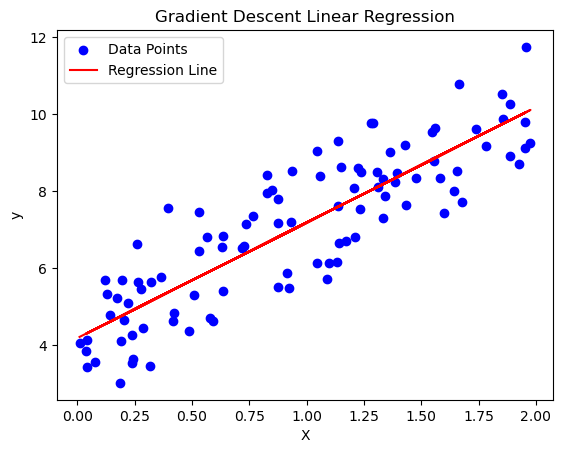

In [ ]:
# Gradient Descent Algorithm from scratch in Python

import numpy as np
import matplotlib.pyplot as plt

class GradientDescent:
    def __init__(self, learning_rate=0.01, n_iters=1000):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.weights = None     # Slope (m)
        self.bias = None    # Intercept (b)
        self.cost_history = []      # To store cost at each iteration

    def fit(self, X, y):
        n_samples, n_features = X.shape
        y= y.flatten()  # Flatten y to ensure it's a 1D array
        # Initialize weights and bias
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Gradient Descent Algorithm
        for i in range(self.n_iters):
            # Calculate predictions
            y_predicted = np.dot(X, self.weights) + self.bias
            
            # Calculate gradients
            dw = (2 / n_samples) * np.dot(X.T, (y_predicted - y)) #Transpose X to match dimensions. The dor product will give us the sum of the products of the errors and the features, which is what we need to update the weights.
            db = (2 / n_samples) * np.sum(y_predicted - y)
            
            # Update weights and bias
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            
            # Calculate cost (Mean Squared Error)
            cost = (1 / n_samples) * np.sum((y_predicted - y) ** 2)
            self.cost_history.append(cost)

            if i % 100 == 0:
                print(f"Iteration {i}: Cost {cost:.4f}")

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias


# Example usage
np.random.seed(0)
X = 2 * np.random.rand(100, 1)  # 100 samples
y = 4 + 3 * X + np.random.randn(100, 1)
model = GradientDescent(learning_rate=0.01, n_iters=1000)
model.fit(X, y)
predictions = model.predict(X)

plt.scatter(X, y, color='blue', label='Data Points')
plt.plot(X, predictions, color='red', label='Regression Line')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Gradient Descent Linear Regression')
plt.legend()
plt.show()

## Hinge Loss in Perceptron Learning
In perceptron learning, the hinge loss is used as a cost function to measure the error between the predicted output and the actual output. The hinge loss is defined as:
```math
L(w, b) = \sum_{i=1}^{n} \max(0, 1 - y_i (w \cdot x_i + b))
```
Where 
- $w$ is the weight vector 
- $b$ is the bias
- $y_i$ is the actual label of the $i$-th training example
- $x_i$ is the feature vector of the $i$-th training example.
- $w \cdot x_i + b$ gives the predicted output for the $i$-th training example.

The hinge loss penalizes misclassified examples and those that are correctly classified but within a margin of 1 from the decision boundary. The goal of perceptron learning is to minimize this hinge loss to find the optimal weights and bias for the model.

Example: Let, $y_i = [1,1,-1,-1]$ and $w \cdot x_i + b = [0.5, 0.8, -0.3, -0.6]$. The hinge loss for each example can be calculated as follows:
- For the first example: $L_1 = \max(0, 1 - 1 \cdot 0.5) = \max(0, 0.5) = 0.5$
- For the second example: $L_2 = \max(0, 1 - 1 \cdot 0.8) = \max(0, 0.2) = 0.2$
- For the third example: $L_3 = \max(0, 1 - (-1) \cdot (-0.3)) = \max(0, 1 - 0.3) = \max(0, 0.7) = 0.7$
- For the fourth example: $L_4 = \max(0, 1 - (-1) \cdot (-0.6)) = \max(0, 1 - 0.6) = \max(0, 0.4) = 0.4$
The total hinge loss for the dataset would be $L = L_1 + L_2 + L_3 + L_4 = 0.5 + 0.2 + 0.7 + 0.4 = 1.8$. This loss can be minimized by adjusting the weights and bias using gradient descent, which will help the perceptron model to better classify the training examples.

To find the minimum hinge loss:
```math
L(w, b) = \arg\min_{w, b} \sum_{i=1}^{n} \max(0, 1 - y_i (w \cdot x_i + b))
```
```math
w:= w - \alpha \frac{\partial L(w, b)}{\partial w}\\
b:= b - \alpha \frac{\partial L(w, b)}{\partial b}
```



### Perceptron Learning vs Gradient Descent
| Feature | Perceptron Learning Rule | Gradient Descent |
| :--- | :--- | :--- |
| Data requirement | Requires data to be linearly separable to converge | Can handle overlapping/non-linearly separable data |
| Update method | Discrete updates: $w \leftarrow w + \eta(y - \hat{y})x$ | Smooth updates using gradient of a loss function: $w \leftarrow w - \eta \frac{\partial L}{\partial w}$ |
| Convergence guarantee | Only guaranteed if data is linearly separable | Can converge to minimum of loss, even if perfect separation not possible |
| Step control | Fixed learning rate; can overshoot | Learning rate can be tuned; can use momentum, scheduling to improve convergence |
| Error measurement | Implicit; only cares about correct/incorrect classification | Explicit; minimizes continuous loss function like MSE or cross-entropy |
| Flexibility | Works only for single-layer perceptron | Works for single-layer and multi-layer networks (MLPs) |


##### Gradient descent usually updates weights by subtracting the gradient. Why does the perceptron update rule add the term ( $\eta, y, x$ ) instead?
The perceptron update rule adds the term $(\eta, y, x)$ because it is trying to correct misclassified examples. The update is designed to move the weight vector in a direction that reduces classification errors. Specifically, if an example is misclassified (i.e., $y \cdot (w \cdot x + b) < 0$), the update moves $w$ in the direction of $x$, which helps to increase the margin between classes. This is different from gradient descent, which updates weights based on minimizing a continuous loss function. In gradient descent, the update is based on the gradient of the loss function, which can be negative or positive, and the weights are adjusted accordingly to minimize the loss. In contrast, the perceptron update is a discrete step that directly addresses misclassifications, hence it adds the term to correct the weights in the direction of the input features.